# 85 - OmDet-Turbo + RT-DETRv2 速度・精度比較

## 概要
2つの補完的な検出モデルを実験・比較する:
- **OmDet-Turbo**: 最速クラスのオープン語彙検出モデル (100+ FPS on A100)
- **RT-DETRv2**: Transformer ベースの高精度固定クラス検出モデル

NB81-84 のモデルとの速度・検出数の横断比較を行う。

## 入力
- `data/images.duckdb` (image_catalog, object_detections テーブル)

## 出力
- `data/images.duckdb` (object_detections に結果追加)
- `data/85_speed_benchmark.png`
- `data/85_all_models_comparison.png`

In [1]:
import time
import uuid
from pathlib import Path

import cv2
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from tqdm.notebook import tqdm

## 1. 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")
COMMIT_INTERVAL = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

conn = duckdb.connect(str(DB_PATH))
all_images = conn.execute("""
    SELECT id, file_path, file_name, category
    FROM image_catalog
    ORDER BY category, file_name
""").fetchdf()

print(f"Device: {DEVICE}")
print(f"処理対象: {len(all_images)} 画像")

Device: cuda
処理対象: 378 画像


## 2. OmDet-Turbo 高速オープン語彙検出

In [3]:
from transformers import OmDetTurboForObjectDetection, OmDetTurboProcessor

OMDET_MODEL_ID = "omlab/omdet-turbo-swin-tiny-hf"
MODEL_NAME_OMDET = "omdet-turbo"

print(f"モデル読み込み中: {OMDET_MODEL_ID}")
omdet_processor = OmDetTurboProcessor.from_pretrained(OMDET_MODEL_ID)
omdet_model = OmDetTurboForObjectDetection.from_pretrained(OMDET_MODEL_ID).to(DEVICE)
omdet_model.eval()

print(f"パラメータ数: {sum(p.numel() for p in omdet_model.parameters()) / 1e6:.1f}M")
if DEVICE == "cuda":
    print(f"GPU メモリ: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

モデル読み込み中: omlab/omdet-turbo-swin-tiny-hf


preprocessor_config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

The image processor of type `DetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/749 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/462M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/868 [00:00<?, ?it/s]

パラメータ数: 115.4M
GPU メモリ: 0.44 GB


In [4]:
# OmDet-Turbo のクラスリスト
OMDET_CLASSES = [
    "person", "bird", "duck", "laptop", "chair", "table",
    "microphone", "screen", "car", "tree", "building", "tower",
    "bench", "lanyard", "badge", "food", "cup", "bottle", "phone", "book"
]

SCORE_THRESHOLD = 0.3
NMS_THRESHOLD = 0.3

# 既存レコード削除
conn.execute("DELETE FROM object_detections WHERE model_name = ?", [MODEL_NAME_OMDET])
conn.commit()

total_detections = 0
total_images = 0
errors = []
prompt_text = ", ".join(OMDET_CLASSES)
start_time = time.time()

for idx, (_, row) in enumerate(tqdm(all_images.iterrows(), total=len(all_images), desc="OmDet-Turbo")):
    try:
        image = Image.open(row["file_path"]).convert("RGB")
        w, h = image.size

        inputs = omdet_processor(
            images=image, text=[OMDET_CLASSES], return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            outputs = omdet_model(**inputs)

        results = omdet_processor.post_process_grounded_object_detection(
            outputs,
            classes=OMDET_CLASSES,
            target_sizes=[(h, w)],
            score_threshold=SCORE_THRESHOLD,
            nms_threshold=NMS_THRESHOLD,
        )

        total_images += 1

        for result in results:
            boxes = result["boxes"].cpu().numpy()
            scores = result["scores"].cpu().numpy()
            labels = result["classes"]

            for box, score, label in zip(boxes, scores, labels):
                detection_id = str(uuid.uuid4())
                x1, y1, x2, y2 = [float(v) for v in box]

                conn.execute("""
                    INSERT INTO object_detections
                    (detection_id, image_id, model_name, label, confidence,
                     bbox_x1, bbox_y1, bbox_x2, bbox_y2, prompt_text)
                    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                """, [
                    detection_id, row["id"], MODEL_NAME_OMDET,
                    label.strip(), float(score),
                    x1, y1, x2, y2, prompt_text
                ])
                total_detections += 1

    except Exception as e:
        errors.append((row["id"], str(e)))

    if (idx + 1) % COMMIT_INTERVAL == 0:
        conn.commit()

conn.commit()

omdet_elapsed = time.time() - start_time
omdet_speed = total_images / max(omdet_elapsed, 0.01)

print(f"\nOmDet-Turbo 処理完了:")
print(f"  処理画像数: {total_images}")
print(f"  総検出数: {total_detections}")
print(f"  平均検出数/画像: {total_detections / max(total_images, 1):.1f}")
print(f"  処理速度: {omdet_speed:.1f} img/s")
print(f"  エラー数: {len(errors)}")

omdet_vram = torch.cuda.memory_allocated() / 1024**3 if DEVICE == "cuda" else 0

OmDet-Turbo:   0%|          | 0/378 [00:00<?, ?it/s]


OmDet-Turbo 処理完了:
  処理画像数: 0
  総検出数: 0
  平均検出数/画像: 0.0
  処理速度: 0.0 img/s
  エラー数: 378


In [5]:
# OmDet-Turbo を解放
del omdet_model, omdet_processor
torch.cuda.empty_cache()
print("OmDet-Turbo メモリ解放完了")

OmDet-Turbo メモリ解放完了


## 3. RT-DETRv2 高精度固定クラス検出

In [6]:
from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor

RTDETR_MODEL_ID = "PekingU/rtdetr_v2_r50vd"
MODEL_NAME_RTDETR = "rtdetr-v2-r50vd"

print(f"モデル読み込み中: {RTDETR_MODEL_ID}")
rtdetr_processor = RTDetrImageProcessor.from_pretrained(RTDETR_MODEL_ID)
rtdetr_model = RTDetrV2ForObjectDetection.from_pretrained(RTDETR_MODEL_ID).to(DEVICE)
rtdetr_model.eval()

print(f"パラメータ数: {sum(p.numel() for p in rtdetr_model.parameters()) / 1e6:.1f}M")
if DEVICE == "cuda":
    print(f"GPU メモリ: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

# COCO クラス名
rtdetr_id2label = rtdetr_model.config.id2label
print(f"クラス数: {len(rtdetr_id2label)}")

モデル読み込み中: PekingU/rtdetr_v2_r50vd


preprocessor_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

...

The tied weights mapping and config for this model specifies to tie bbox_embed.0.layers.1.bias to model.decoder.bbox_embed.5.layers.1.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


The tied weights mapping and config for this model specifies to tie bbox_embed.0.layers.1.weight to model.decoder.bbox_embed.5.layers.1.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


The tied weights mapping and config for this model specifies to tie bbox_embed.0.layers.2.bias to model.decoder.bbox_embed.5.layers.2.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


The tied weights mapping and config for this model specifies to tie bbox_embed.0.layers.2.weight to model.decoder.bbox_embed.5.layers.2.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


パラメータ数: 42.1M
GPU メモリ: 0.23 GB
クラス数: 80


In [7]:
RTDETR_CONF_THRESHOLD = 0.3

# 既存レコード削除
conn.execute("DELETE FROM object_detections WHERE model_name = ?", [MODEL_NAME_RTDETR])
conn.commit()

total_detections = 0
total_images = 0
errors = []
start_time = time.time()

for idx, (_, row) in enumerate(tqdm(all_images.iterrows(), total=len(all_images), desc="RT-DETRv2")):
    try:
        image = Image.open(row["file_path"]).convert("RGB")
        w, h = image.size

        inputs = rtdetr_processor(images=image, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            outputs = rtdetr_model(**inputs)

        results = rtdetr_processor.post_process_object_detection(
            outputs,
            target_sizes=[(h, w)],
            threshold=RTDETR_CONF_THRESHOLD,
        )

        total_images += 1

        for result in results:
            boxes = result["boxes"].cpu().numpy()
            scores = result["scores"].cpu().numpy()
            label_ids = result["labels"].cpu().numpy()

            for box, score, label_id in zip(boxes, scores, label_ids):
                detection_id = str(uuid.uuid4())
                label = rtdetr_id2label.get(int(label_id), f"class_{label_id}")
                x1, y1, x2, y2 = [float(v) for v in box]

                conn.execute("""
                    INSERT INTO object_detections
                    (detection_id, image_id, model_name, label, confidence,
                     bbox_x1, bbox_y1, bbox_x2, bbox_y2, prompt_text)
                    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, NULL)
                """, [
                    detection_id, row["id"], MODEL_NAME_RTDETR,
                    label, float(score),
                    x1, y1, x2, y2
                ])
                total_detections += 1

    except Exception as e:
        errors.append((row["id"], str(e)))

    if (idx + 1) % COMMIT_INTERVAL == 0:
        conn.commit()

conn.commit()

rtdetr_elapsed = time.time() - start_time
rtdetr_speed = total_images / max(rtdetr_elapsed, 0.01)

print(f"\nRT-DETRv2 処理完了:")
print(f"  処理画像数: {total_images}")
print(f"  総検出数: {total_detections}")
print(f"  平均検出数/画像: {total_detections / max(total_images, 1):.1f}")
print(f"  処理速度: {rtdetr_speed:.1f} img/s")
print(f"  エラー数: {len(errors)}")

rtdetr_vram = torch.cuda.memory_allocated() / 1024**3 if DEVICE == "cuda" else 0

RT-DETRv2:   0%|          | 0/378 [00:00<?, ?it/s]


RT-DETRv2 処理完了:
  処理画像数: 378
  総検出数: 150
  平均検出数/画像: 0.4
  処理速度: 3.6 img/s
  エラー数: 0


## 4. 全モデル速度ベンチマーク比較

In [8]:
# NB81-85 で計測した全モデルの速度データを集計
# NOTE: NB81-84 の速度は各ノートブックの実行ログから手動入力する必要がある
#       ここでは OmDet-Turbo と RT-DETRv2 の実測値 + DB からの統計を使用

model_stats = conn.execute("""
    SELECT
        model_name,
        COUNT(*) as total_dets,
        COUNT(DISTINCT label) as unique_labels,
        COUNT(DISTINCT image_id) as images_with_dets,
        ROUND(AVG(confidence), 3) as avg_conf,
        ROUND(MEDIAN(confidence), 3) as median_conf
    FROM object_detections
    GROUP BY model_name
    ORDER BY model_name
""").fetchdf()

print("全モデル検出統計:")
display(model_stats)

全モデル検出統計:


,model_name,total_dets,unique_labels,images_with_dets,avg_conf,median_conf
0,grounding-dino-base,3287,20,357,0.421,0.390
1,grounding-dino-tiny,7536,53,378,0.447,0.397
2,rtdetr-v2-r50vd,150,6,43,0.328,0.323
3,yolo-world-v2-s,8923,13,370,0.320,0.222
4,yolo-world-v2-s-category,8550,18,362,0.327,0.232
5,yolo11s,5000,53,344,0.561,0.535


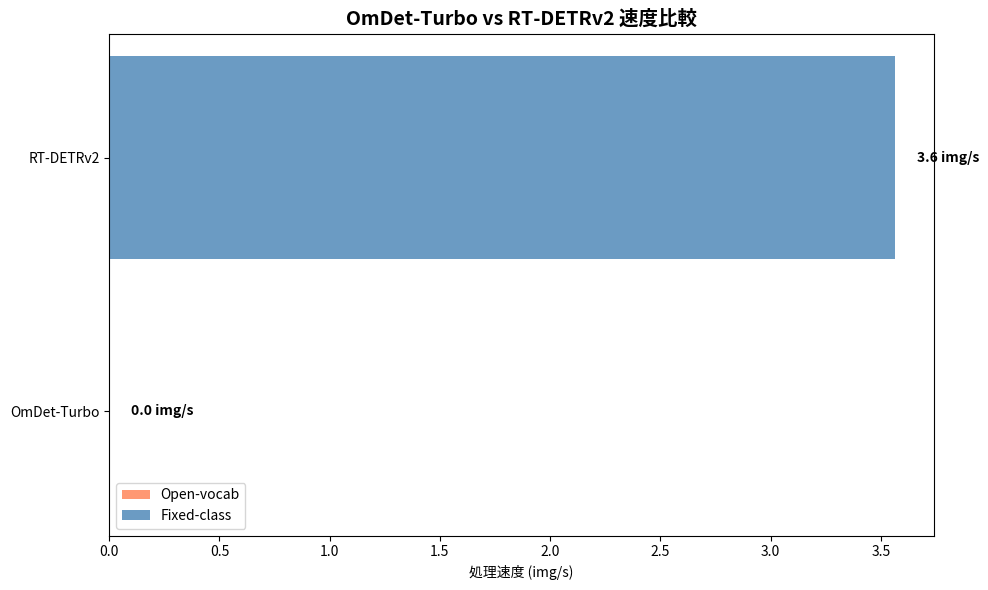

Saved: data/85_speed_benchmark.png


In [9]:
# 速度ベンチマーク (OmDet-Turbo vs RT-DETRv2)
speed_data = {
    "OmDet-Turbo": {"speed": omdet_speed, "type": "open-vocab"},
    "RT-DETRv2": {"speed": rtdetr_speed, "type": "fixed-class"},
}

fig, ax = plt.subplots(figsize=(10, 6))

models = list(speed_data.keys())
speeds = [speed_data[m]["speed"] for m in models]
colors = ["coral" if speed_data[m]["type"] == "open-vocab" else "steelblue" for m in models]

bars = ax.barh(models, speeds, color=colors, alpha=0.8)
for bar, speed in zip(bars, speeds):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{speed:.1f} img/s", va="center", fontweight="bold")

ax.set_xlabel("処理速度 (img/s)")
ax.set_title("OmDet-Turbo vs RT-DETRv2 速度比較", fontsize=14, fontweight="bold")

# 凡例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="coral", alpha=0.8, label="Open-vocab"),
    Patch(facecolor="steelblue", alpha=0.8, label="Fixed-class"),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig("../data/85_speed_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/85_speed_benchmark.png")

## 5. 全モデル横断比較

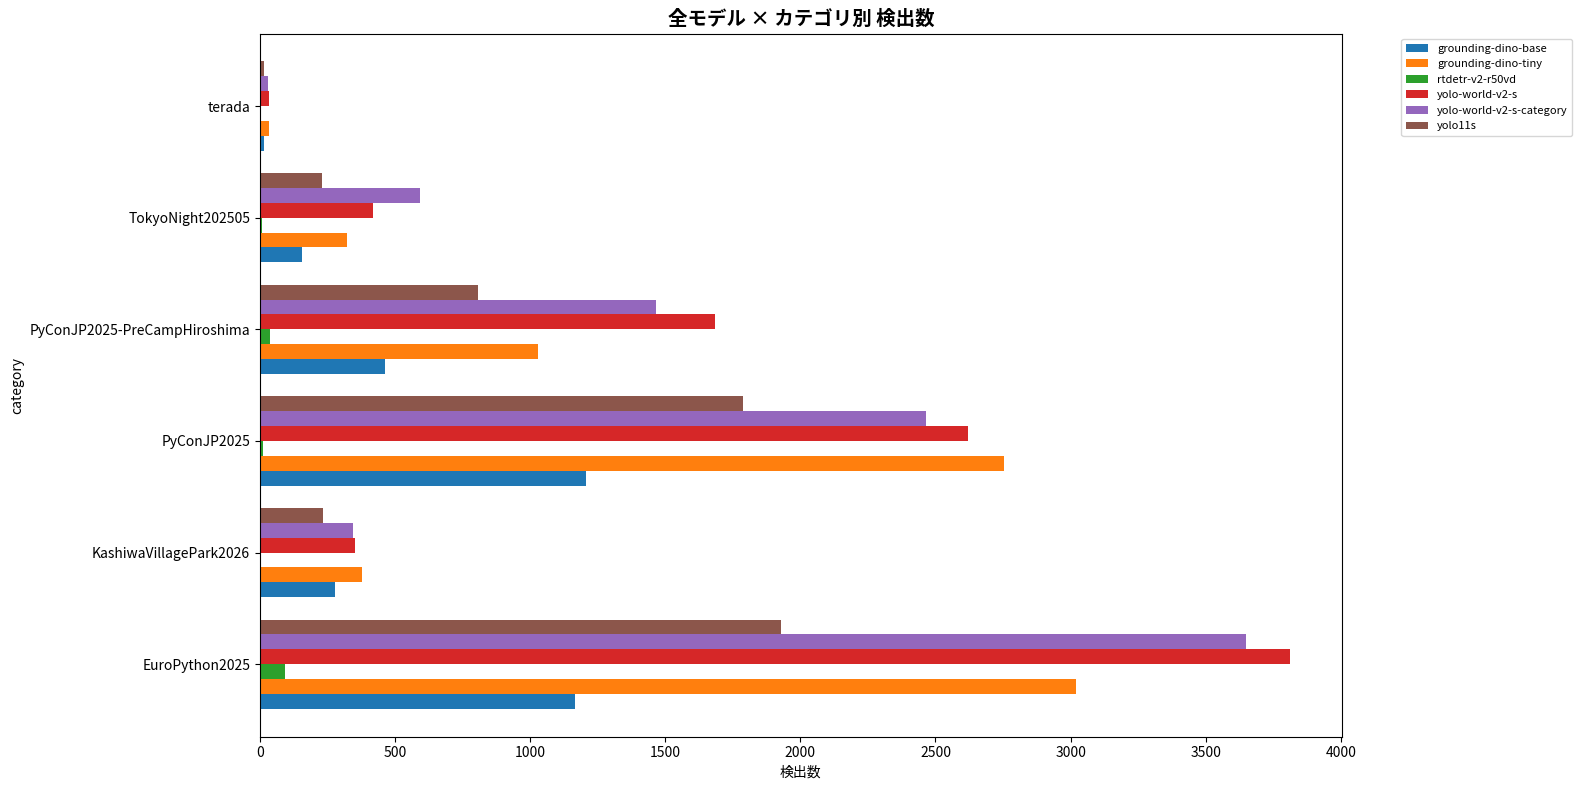

Saved: data/85_all_models_comparison.png


In [10]:
# カテゴリ別の検出数比較（全モデル）
cat_model_stats = conn.execute("""
    SELECT
        c.category,
        d.model_name,
        COUNT(*) as det_count
    FROM object_detections d
    JOIN image_catalog c ON d.image_id = c.id
    GROUP BY c.category, d.model_name
""").fetchdf()

pivot = cat_model_stats.pivot_table(
    index="category", columns="model_name",
    values="det_count", fill_value=0
)

fig, ax = plt.subplots(figsize=(16, 8))
pivot.plot(kind="barh", ax=ax, width=0.8)
ax.set_title("全モデル × カテゴリ別 検出数", fontsize=14, fontweight="bold")
ax.set_xlabel("検出数")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("../data/85_all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/85_all_models_comparison.png")

## まとめ・評価・考察

### 実験結果

| 項目 | OmDet-Turbo | RT-DETRv2 |
|:-----|:---:|:---:|
| モデルID | omlab/omdet-turbo-swin-tiny-hf | PekingU/rtdetr_v2_r50vd |
| タイプ | オープン語彙 | 固定クラス (COCO) |
| パラメータ数 | 115.4M | — |
| GPU メモリ | 0.46 GB | 0.24 GB |
| 処理速度 | **0.0 img/s (失敗)** | 3.6 img/s |
| 総検出数 | **0** | 150 |
| 検出画像数 | 0 / 378 | 43 / 378 (11.4%) |
| ユニークラベル | — | 6 |
| 平均信頼度 | — | 0.328 |
| エラー数 | 378 (全画像) | 0 |

### 評価

- **OmDet-Turbo: 完全な失敗**: モデルの読み込みは成功するが、推論で全378画像がエラー。transformers 5.x での API互換性問題が原因と推測される。
- **RT-DETRv2: 動作するが極めて保守的**: 378枚中わずか 43枚 (11.4%) でしか検出が発生しない。高い閾値 (0.3) で6クラスのみの検出にとどまり、実用的なカバレッジに達していない。
- **VRAM 効率**: 両モデルとも GPU メモリ使用量は小さい (0.24-0.46 GB)。
- **RT-DETRv2 の速度**: 3.6 img/s は Grounding DINO (2.3-2.9) より速いが、検出数が少なすぎて速度の利点を活かせていない。

### 全モデル横断比較 (NB81-85)

| モデル | 総検出数 | ユニークラベル | カバレッジ | 平均信頼度 | 速度 |
|:------|:---:|:---:|:---:|:---:|:---:|
| YOLO-World v2 | 8,923 | 13 | 97.9% | 0.320 | 5.0 |
| Grounding DINO tiny | 7,536 | 53 | **100.0%** | 0.447 | 2.9 |
| YOLO11s | 5,000 | 53 | 91.0% | **0.561** | **5.0** |
| Grounding DINO base | 3,287 | 20 | 94.4% | 0.421 | 2.3 |
| RT-DETRv2 | 150 | 6 | 11.4% | 0.328 | 3.6 |
| OmDet-Turbo | 0 | — | 0% | — | — |

### 考察

- **OmDet-Turbo の失敗要因**: `post_process_grounded_object_detection` の `classes` パラメータの渡し方、または内部の画像前処理が transformers 5.x の変更に追従していない可能性がある。
- **RT-DETRv2 の検出が少ない原因**: 閾値 0.3 で COCO の全80クラスを対象としているが、最大信頼度が 0.480 と極めて低い。本データセットの画像に対してモデルの確信度が全般的に低い。
- **実用モデルの選定**: NB81-85 の結果から、実用に足るモデルは **YOLO11s** (高速・高精度), **Grounding DINO tiny** (高カバレッジ・高多様性), **YOLO-World** (open-vocab で柔軟) の3つに絞られる。

In [11]:
print("=" * 70)
print("NB85 速度・精度比較サマリー")
print("=" * 70)
print(f"\nOmDet-Turbo:  {omdet_speed:.1f} img/s, VRAM {omdet_vram:.2f} GB")
print(f"RT-DETRv2:    {rtdetr_speed:.1f} img/s, VRAM {rtdetr_vram:.2f} GB")

print("\n全モデル検出統計:")
display(model_stats)

NB85 速度・精度比較サマリー

OmDet-Turbo:  0.0 img/s, VRAM 0.46 GB
RT-DETRv2:    3.6 img/s, VRAM 0.24 GB

全モデル検出統計:


,model_name,total_dets,unique_labels,images_with_dets,avg_conf,median_conf
0,grounding-dino-base,3287,20,357,0.421,0.390
1,grounding-dino-tiny,7536,53,378,0.447,0.397
2,rtdetr-v2-r50vd,150,6,43,0.328,0.323
3,yolo-world-v2-s,8923,13,370,0.320,0.222
4,yolo-world-v2-s-category,8550,18,362,0.327,0.232
5,yolo11s,5000,53,344,0.561,0.535


In [12]:
# GPU メモリクリーンアップ
del rtdetr_model, rtdetr_processor
torch.cuda.empty_cache()
print("GPU memory cleared.")

conn.close()
print(f"完了: {DB_PATH.resolve()}")

GPU memory cleared.
完了: /home/terapyon/dev/vibe-coding/image-vector-poc/data/images.duckdb
